In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv')

In [ ]:
df.head() # data looks clean

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.tail() # data looks clean

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
df.info() # 8807 records, 1 int column rest object and there are some columns with NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [ ]:
#show_id is the unique per record
#type has 2 values i.e. Movie and TV Show
#title represents content name and has unique values for all records
#content from 4528 different directors are available
#data for around 7692 unique combinations of star cast is present
#content is currenly streamed in several countries
#content available from year 1925 till recently suggesting tremendous coverage
#data also has the runtime per content, censorship ratings and a summary of the content

In [ ]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
len(df.loc[df.isnull().values.any(axis=1),:])

3475

In [ ]:
# 2634 Rows have Nan for Directors
# 824 Rows have Nan for cast
# 831 Rows have Nan for country
# 3475 records have atleast 1 column as Nan

In [ ]:
# Filling Nan with some meeaning full data
df['director']=df['director'].fillna('other')
df['country']=df['country'].fillna('other')
df['cast']=df['cast'].fillna('not_known')
df['date_added']=df['date_added'].fillna('not_known')
df['rating']=df['rating'].fillna('not_known')
df['duration']=df['duration'].fillna('not_known')

Movie      6131
TV Show    2676
Name: type, dtype: int64


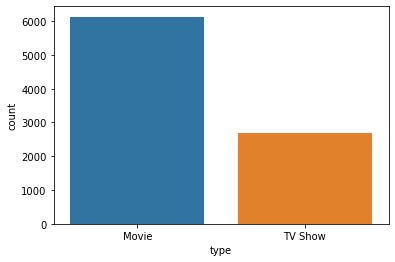

In [ ]:
print(df['type'].value_counts())
sns.countplot(data=df, x = 'type')
plt.show()

In [ ]:
#2 types of content available
#Around 6131 movies and 2676 TV Shows


TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
not_known       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: rating, dtype: int64


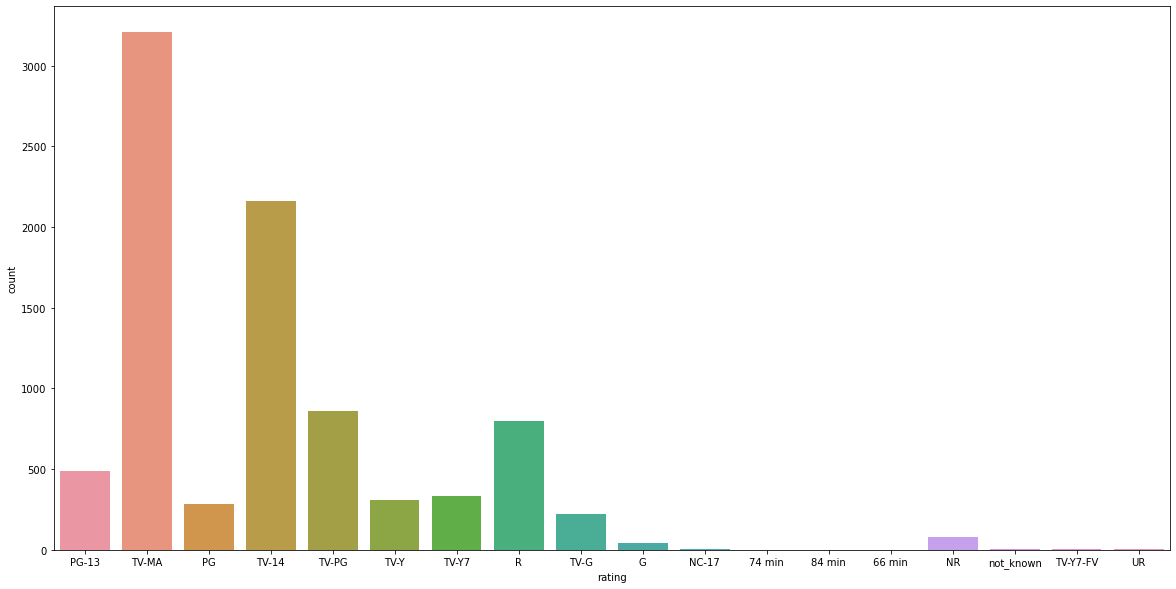

In [ ]:
plt.figure(figsize=(20,10))
print(df['rating'].value_counts())
sns.countplot(data=df,x='rating')
plt.show()

In [ ]:
#TV-MA have most content followed by TV-14
#There is less conetent for kids

rating     type   
66 min     Movie         1
74 min     Movie         1
84 min     Movie         1
G          Movie        41
NC-17      Movie         3
NR         Movie        75
           TV Show       5
PG         Movie       287
PG-13      Movie       490
R          Movie       797
           TV Show       2
TV-14      Movie      1427
           TV Show     733
TV-G       Movie       126
           TV Show      94
TV-MA      Movie      2062
           TV Show    1145
TV-PG      Movie       540
           TV Show     323
TV-Y       Movie       131
           TV Show     176
TV-Y7      Movie       139
           TV Show     195
TV-Y7-FV   Movie         5
           TV Show       1
UR         Movie         3
not_known  Movie         2
           TV Show       2
Name: show_id, dtype: int64


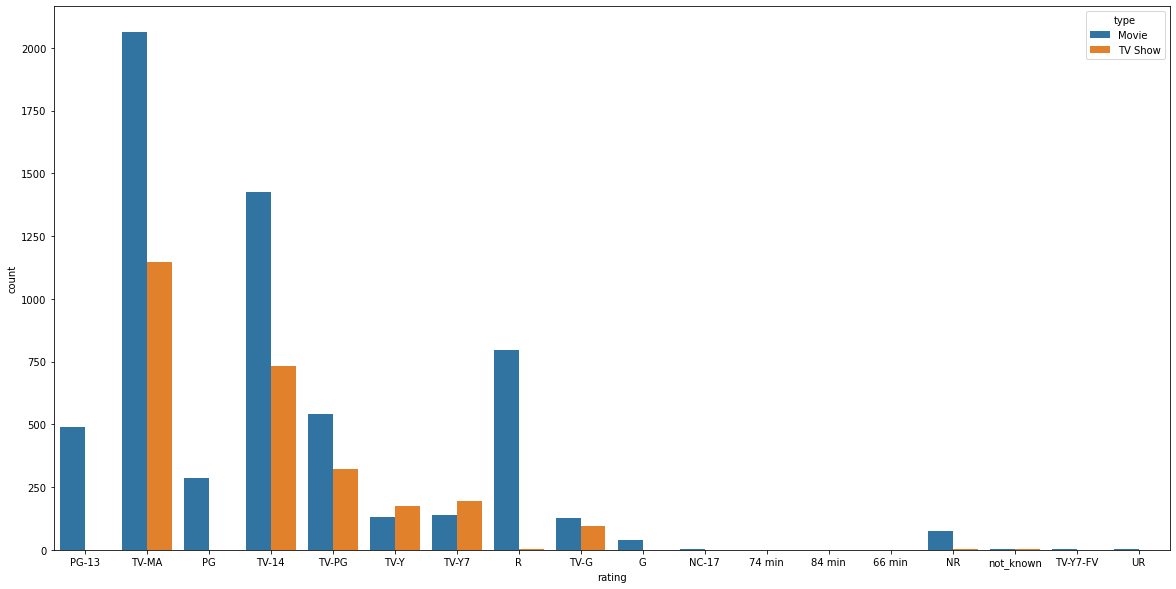

In [ ]:
plt.figure(figsize=(20,10))
print(df.groupby(['rating','type'])['show_id'].count())
sns.countplot(data=df,x='rating',hue='type')
plt.show()

In [ ]:
#movies in all rating have more content then Tv Show except TV-Y and TV-Y7
#There is less conetent for kids

4728


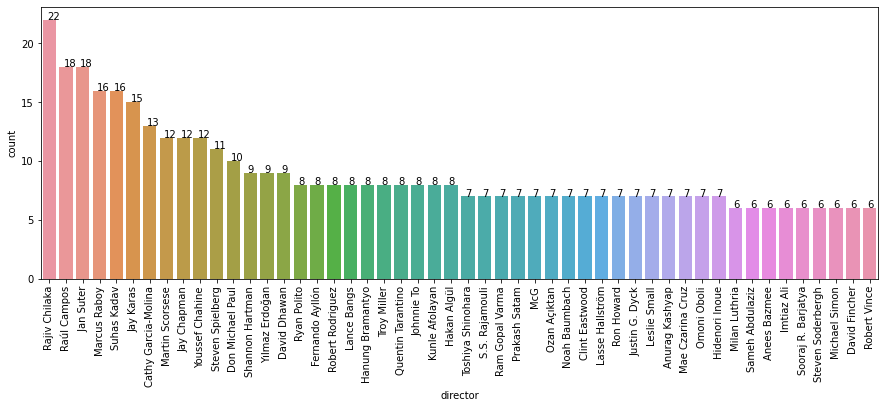

In [ ]:
df_dir=df.copy()
df_dir.drop(df_dir[df_dir['director'] == 'other'].index, inplace = True)
df_dir=df_dir.assign(director=df_dir['director'].str.split(',')).explode('director')
count_val = df_dir['director'].value_counts()
print(count_val[count_val.values <= 2].index.to_series().count())
dir = df_dir['director'].value_counts().head(50).index

plt.figure(figsize=(15,5))
plot = sns.countplot(data=df_dir, x = 'director', order = dir)
plot.set_xticklabels(labels=dir, rotation=90)
for p in plot.patches:
 plot.annotate('{:}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
plt.show()

In [ ]:
#Rajiv Chilaka has the maximum number of contents available i.e. 22 closely followed by Jan Suter with 18
#Around 4728 directors have 2 or lesser content available which is more than 96% percent. This looks like an area of concern

34118


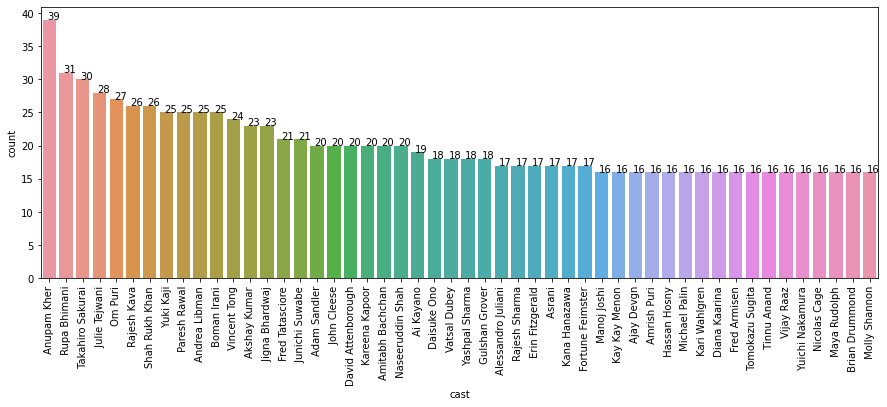

In [ ]:
df_exp=df.copy()
df_exp.drop(df_exp[df_exp['cast'] == 'not_known'].index, inplace = True)
df_exp=df_exp.assign(cast=df_exp['cast'].str.split(',')).explode('cast')
count_val = df_exp['cast'].value_counts()
print(count_val[count_val.values <= 2].index.to_series().count())
dir = df_exp['cast'].value_counts().head(50).index

plt.figure(figsize=(15,5))
plot = sns.countplot(data=df_exp, x = 'cast', order = dir)
plot.set_xticklabels(labels=dir, rotation=90)
for p in plot.patches:
 plot.annotate('{:}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
plt.show()

In [ ]:

#Anupam Kher has the maximum number of contents available i.e. 43 closely followed by famous Indian actor Shah Rukh Khan with
#35 and Julie Tejwani with 33

#Around 34118 directors have 2 or lesser content available which is more than 91% percent.
#This again looks like an area of concern

77
United States     3211
India             1008
United Kingdom     628
 United States     479
Canada             271
                  ... 
 Ecuador             1
Iran                 1
Cyprus               1
 Mongolia            1
 Montenegro          1
Name: country, Length: 197, dtype: int64


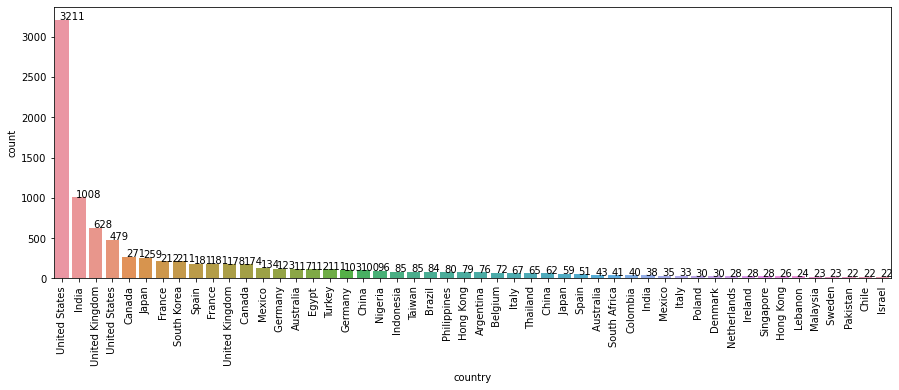

In [ ]:
df_cr=df.copy()
df_cr.drop(df_cr[df_cr['country'] == 'other'].index, inplace = True)
df_cr=df_cr.assign(country=df_cr['country'].str.split(',')).explode('country')
count_val = df_cr['country'].value_counts()
print(count_val[count_val.values <= 2].index.to_series().count())
dir = df_cr['country'].value_counts().head(50).index
print(df_cr['country'].value_counts())

plt.figure(figsize=(15,5))
plot = sns.countplot(data=df_cr, x = 'country', order = dir)
plot.set_xticklabels(labels=dir, rotation=90)
for p in plot.patches:
 plot.annotate('{:}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
plt.show()

In [ ]:
#US has maximum amount of contents available at 3211

4


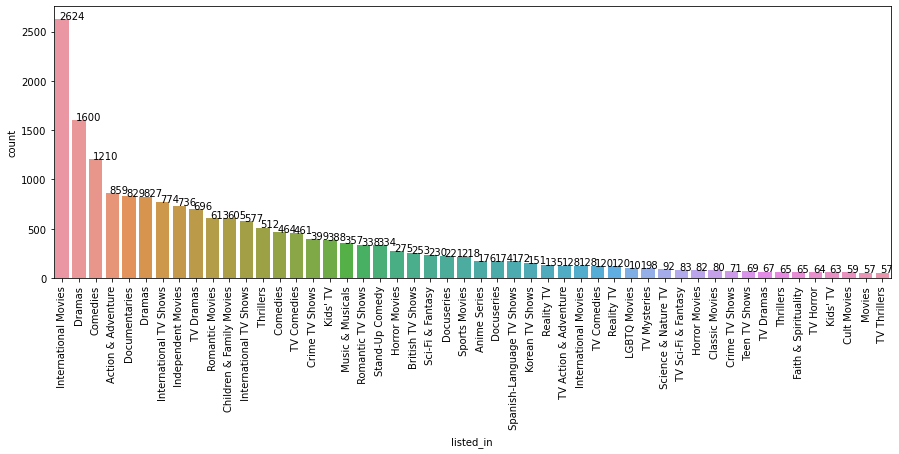

In [ ]:
df_l=df.copy()
df_l.drop(df_l[df_l['listed_in'] == 'not_known'].index, inplace = True)
df_l=df_l.assign(listed_in=df_l['listed_in'].str.split(',')).explode('listed_in')
count_val = df_l['listed_in'].value_counts()
print(count_val[count_val.values <= 2].index.to_series().count())
dir = df_l['listed_in'].value_counts().head(50).index

plt.figure(figsize=(15,5))
plot = sns.countplot(data=df_l, x = 'listed_in', order = dir)
plot.set_xticklabels(labels=dir, rotation=90)
for p in plot.patches:
 plot.annotate('{:}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
plt.show()

In [ ]:
#Around 2624 International movies are available closely followed by 1600 dramas
# we can work on content with less counts like horror movies


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,not_known,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",other,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",other,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",other,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."


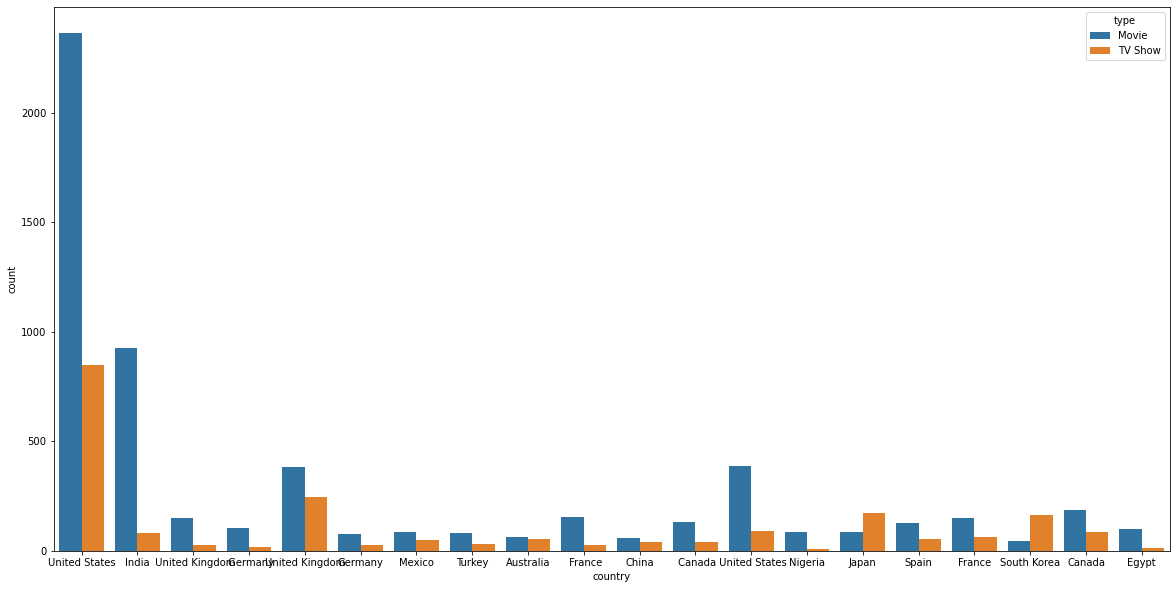

In [ ]:
plt.figure(figsize=(20,10))
cnt = df_cr['country'].value_counts().head(20).index
df1=df_cr.loc[df_cr['country'].isin(cnt)]
sns.countplot(data=df1,x='country',hue='type')

plt.show()

In [ ]:
df1

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,not_known,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,other,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,other,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United Kingdom,"September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8800,s8801,TV Show,Zindagi Gulzar Hai,other,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
